# Kaya Decomposition Dashboard Tutorial

This notebook demonstrates how to create Kaya decomposition dashboards using data from the IIASA database.

We'll recreate the figures from the Excel workbook `vanVuurenIMAGE_15_TOT_19_TFC_current.xlsm`:
- **Fig3ExpandKAYAfactorsDEq**: Kaya factors (P, GNP, FE, PEDEq, PEFF, TFC, NFC)
- **Fig4ExpandKAYAratiosDEq**: Kaya ratios (GNP/P, FE/GNP, PEDEq/FE, etc.)

## The Kaya Identity

The Kaya identity decomposes CO2 emissions into contributing factors:

$$CO_2 = P \times \frac{GDP}{P} \times \frac{FE}{GDP} \times \frac{PE}{FE} \times \frac{PE_{FF}}{PE} \times \frac{TFC}{PE_{FF}} \times \frac{NFC}{TFC}$$

Where:
- **P** = Population
- **GDP/P** = GDP per capita (economic activity per person)
- **FE/GDP** = Energy intensity of the economy
- **PE/FE** = Primary to final energy ratio (energy supply losses)
- **PE_FF/PE** = Fossil fuel fraction of primary energy
- **TFC/PE_FF** = Carbon intensity of fossil energy
- **NFC/TFC** = Net to total carbon ratio (accounts for CCS)

## Setup

First, let's import the necessary libraries.

In [10]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyam

from kaya_decomposition import (
    compute_kaya_variables,
    compute_kaya_factors,
    input_variables,
    kaya_variables as kv,
    kaya_factors as kf,
)

warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Configuration

Define the scenarios we want to analyze.

In [11]:
# IIASA Database settings
DATABASE = "iamc15"  # IAMC 1.5°C Scenario Explorer
MODEL = "IMAGE 3.0.1"
REF_SCENARIO = "SSP2-Baseline"  # Reference scenario
INT_SCENARIO = "IMA15-TOT"      # Intervention scenario (1.5°C)
REGION = "World"
BASE_YEAR = 2010  # Index year for normalized plots

print(f"Analyzing {MODEL}")
print(f"  Reference scenario: {REF_SCENARIO}")
print(f"  Intervention scenario: {INT_SCENARIO}")
print(f"  Region: {REGION}")

Analyzing IMAGE 3.0.1
  Reference scenario: SSP2-Baseline
  Intervention scenario: IMA15-TOT
  Region: World


## Step 1: Download Data from IIASA Database

We'll use `pyam.read_iiasa()` to download scenario data directly from the IAMC 1.5°C Scenario Explorer.

In [12]:
# Required variables for Kaya decomposition
REQUIRED_VARIABLES = [
    "Population",
    "GDP|PPP",
    "GDP|MER",
    "Final Energy",
    "Primary Energy",
    "Primary Energy|Coal",
    "Primary Energy|Oil",
    "Primary Energy|Gas",
    "Emissions|CO2|Energy and Industrial Processes",
    "Emissions|CO2|Industrial Processes",
    "Emissions|CO2|AFOLU",
    "Carbon Sequestration|CCS",
    "Carbon Sequestration|CCS|Biomass",
    "Carbon Sequestration|CCS|Fossil|Energy",
    "Carbon Sequestration|CCS|Fossil|Industrial Processes",
    "Carbon Sequestration|CCS|Biomass|Energy",
    "Carbon Sequestration|CCS|Biomass|Industrial Processes",
]

data_for_kaya = pyam.read_iiasa(
    DATABASE,
    model=MODEL,
    scenario=[REF_SCENARIO, INT_SCENARIO],
    region=REGION,
    variable=REQUIRED_VARIABLES,
)

print(f"Downloaded {len(data_for_kaya.data)} data points")
print(f"  Years: {sorted(data_for_kaya.year)}")
print(f"  Variables: {len(data_for_kaya.variable)}")
print(f"  Scenarios: {list(data_for_kaya.scenario)}")

[INFO] 17:26:37 - pyam.iiasa: You are connected to the IXSE_SR15 scenario explorer hosted by IIASA. If you use this data in any published format, please cite the data as provided in the explorer guidelines: https://data.ece.iiasa.ac.at/iamc-1.5c-explorer/#/about
[INFO] 17:26:37 - pyam.iiasa: You are connected as an anonymous user


Downloaded 376 data points
  Years: [2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2060, 2070, 2080, 2090, 2100]
  Variables: 17
  Scenarios: ['IMA15-TOT', 'SSP2-Baseline']


In [13]:
def prepare_data_for_kaya(df):
    """Prepare IIASA data for Kaya decomposition"""
    data = df.data.copy()
    
    # Fix units (remove $ symbols that cause parsing issues)
    unit_mapping = {
        "billion US$2010/yr": "billion USD_2010/yr",
        "billion US$2005/yr": "billion USD_2005/yr",
    }
    for old_unit, new_unit in unit_mapping.items():
        data.loc[data["unit"] == old_unit, "unit"] = new_unit
    
    # Fill missing CCS variables with zeros
    scenarios = data[["model", "scenario", "region"]].drop_duplicates()
    years = data["year"].unique()
    
    zero_fill_vars = [
        "Carbon Sequestration|CCS",
        "Carbon Sequestration|CCS|Biomass",
        "Carbon Sequestration|CCS|Fossil|Energy",
        "Carbon Sequestration|CCS|Fossil|Industrial Processes",
        "Carbon Sequestration|CCS|Biomass|Energy",
        "Carbon Sequestration|CCS|Biomass|Industrial Processes",
        "Emissions|CO2|Industrial Processes",
    ]
    
    for _, row in scenarios.iterrows():
        for var in zero_fill_vars:
            existing = data[
                (data["model"] == row["model"])
                & (data["scenario"] == row["scenario"])
                & (data["region"] == row["region"])
                & (data["variable"] == var)
            ]
            if len(existing) == 0:
                new_rows = []
                for year in years:
                    new_rows.append({
                        "model": row["model"],
                        "scenario": row["scenario"],
                        "region": row["region"],
                        "variable": var,
                        "unit": "Mt CO2/yr",
                        "year": year,
                        "value": 0.0,
                    })
                data = pd.concat([data, pd.DataFrame(new_rows)], ignore_index=True)
    
    return pyam.IamDataFrame(data)

# Prepare the data
prepared_data = prepare_data_for_kaya(data_for_kaya)
print(f"Prepared data has {len(prepared_data.variable)} variables")

Prepared data has 17 variables


In [14]:
# Compute for reference scenario
ref_data = prepared_data.filter(scenario=REF_SCENARIO)
ref_kaya_vars = compute_kaya_variables(ref_data)
ref_kaya_factors = compute_kaya_factors(ref_kaya_vars)

# Compute for intervention scenario
int_data = prepared_data.filter(scenario=INT_SCENARIO)
int_kaya_vars = compute_kaya_variables(int_data)
int_kaya_factors = compute_kaya_factors(int_kaya_vars)

print(f"Computed Kaya decomposition for both scenarios")
print(f"  Variables: {list(ref_kaya_vars.variable)}")
print(f"  Factors: {list(ref_kaya_factors.variable)}")

Computed Kaya decomposition for both scenarios
  Variables: ['Final Energy', 'GDP|PPP', 'Net Fossil Carbon', 'Population', 'Primary Energy', 'Primary Energy|Fossil', 'Total Fossil Carbon']
  Factors: ['FE/GNP', 'GNP/P', 'NFC/TFC', 'PEDEq/FE', 'PEFF/PEDEq', 'Population', 'TFC/PEFF', 'Total Fossil Carbon']


## Step 4: Extract Data for Visualization

Convert to pandas DataFrames with appropriate units for plotting.

In [15]:
def extract_factors(kaya_vars, kaya_factors):
    """Extract Kaya factors as a DataFrame."""
    factors = {}
    
    # Population (billions)
    pop_data = kaya_vars.filter(variable=input_variables.POPULATION).data
    factors["P"] = {int(r["year"]): r["value"] / 1000 for _, r in pop_data.iterrows()}
    
    # GDP (trillions)
    gdp_data = kaya_vars.filter(variable=input_variables.GDP_PPP).data
    factors["GNP"] = {int(r["year"]): r["value"] / 1000 for _, r in gdp_data.iterrows()}
    
    # Final Energy (EJ)
    fe_data = kaya_vars.filter(variable=input_variables.FINAL_ENERGY).data
    factors["FE"] = {int(r["year"]): r["value"] for _, r in fe_data.iterrows()}
    
    # Primary Energy (EJ)
    pe_data = kaya_vars.filter(variable=input_variables.PRIMARY_ENERGY).data
    factors["PEDEq"] = {int(r["year"]): r["value"] for _, r in pe_data.iterrows()}
    
    # Fossil Energy (EJ)
    peff_data = kaya_vars.filter(variable=kv.PRIMARY_ENERGY_FF).data
    factors["PEFF"] = {int(r["year"]): r["value"] for _, r in peff_data.iterrows()}
    
    # Total Fossil Carbon (Gt CO2)
    tfc_data = kaya_vars.filter(variable=kv.TFC).data
    factors["TFC"] = {int(r["year"]): r["value"] / 1000 for _, r in tfc_data.iterrows()}
    
    # Net Fossil Carbon (Gt CO2)
    nfc_data = kaya_vars.filter(variable=kv.NFC).data
    factors["NFC"] = {int(r["year"]): r["value"] / 1000 for _, r in nfc_data.iterrows()}
    
    years = sorted(set.union(*[set(v.keys()) for v in factors.values()]))
    result = pd.DataFrame({"year": years})
    for name, values in factors.items():
        result[name] = result["year"].map(values)
    return result.set_index("year")

def extract_ratios(kaya_factors):
    """Extract Kaya ratios as a DataFrame."""
    ratios = {}
    
    data = kaya_factors.filter(variable=kf.GNP_per_P).data
    ratios["GNP/P"] = {int(r["year"]): r["value"] * 1000 for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.FE_per_GNP).data
    ratios["FE/GNP"] = {int(r["year"]): r["value"] * 1000 for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.PEdeq_per_FE).data
    ratios["PEDEq/FE"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.PEFF_per_PEDEq).data
    ratios["PEFF/PEDEq"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.TFC_per_PEFF).data
    ratios["TFC/PEFF"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.NFC_per_TFC).data
    ratios["NFC/TFC"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    years = sorted(set.union(*[set(v.keys()) for v in ratios.values()]))
    result = pd.DataFrame({"year": years})
    for name, values in ratios.items():
        result[name] = result["year"].map(values)
    return result.set_index("year")

ref_factors = extract_factors(ref_kaya_vars, ref_kaya_factors)
int_factors = extract_factors(int_kaya_vars, int_kaya_factors)
ref_ratios = extract_ratios(ref_kaya_factors)
int_ratios = extract_ratios(int_kaya_factors)

## Step 5: Create Figure 3 - Kaya Factors Dashboard

This shows the absolute values of all Kaya factors over time for both scenarios.

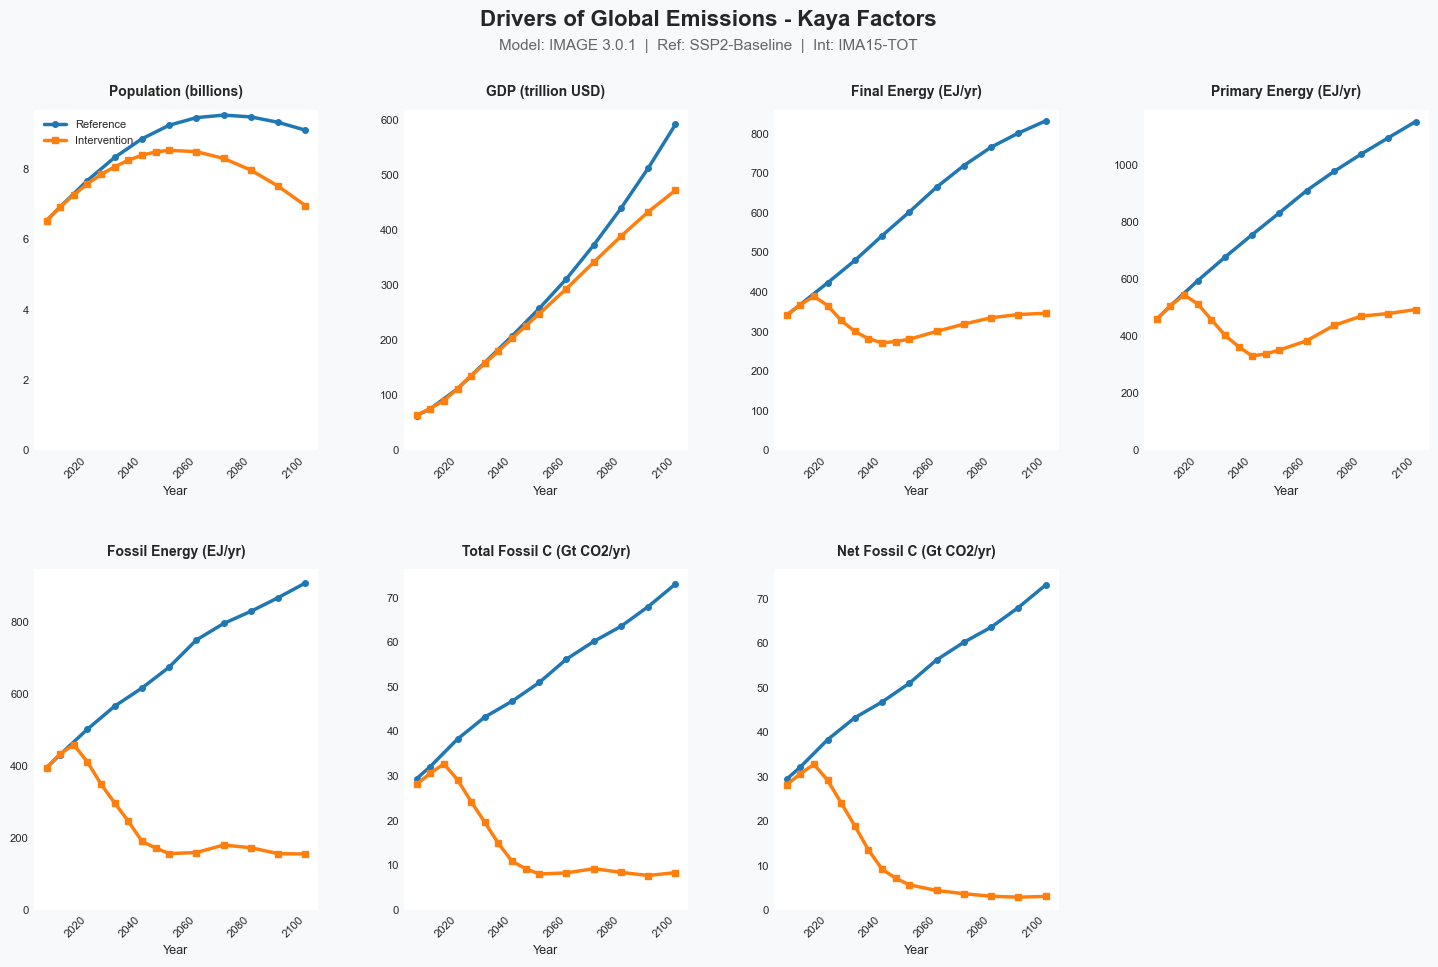

In [18]:
factor_names = ["P", "GNP", "FE", "PEDEq", "PEFF", "TFC", "NFC"]
factor_labels = {
    "P": "Population (billions)",
    "GNP": "GDP (trillion USD)",
    "FE": "Final Energy (EJ/yr)",
    "PEDEq": "Primary Energy (EJ/yr)",
    "PEFF": "Fossil Energy (EJ/yr)",
    "TFC": "Total Fossil C (Gt CO2/yr)",
    "NFC": "Net Fossil C (Gt CO2/yr)",
}

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')

fig.suptitle('Drivers of Global Emissions - Kaya Factors', fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.94, f'Model: {MODEL}  |  Ref: {REF_SCENARIO}  |  Int: {INT_SCENARIO}',
         ha='center', fontsize=11, color='#666')

gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3, top=0.88, bottom=0.08)

for i, factor in enumerate(factor_names):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.set_facecolor('#ffffff')
    
    ax.plot(ref_factors.index, ref_factors[factor], color='#1f77b4', linewidth=2.5, 
            label='Reference', marker='o', markersize=4)
    ax.plot(int_factors.index, int_factors[factor], color='#ff7f0e', linewidth=2.5, 
            label='Intervention', marker='s', markersize=4)
    
    ax.set_title(factor_labels[factor], fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylim(0, None)
    
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax_empty = fig.add_subplot(gs[1, 3])
ax_empty.axis('off')

plt.show()

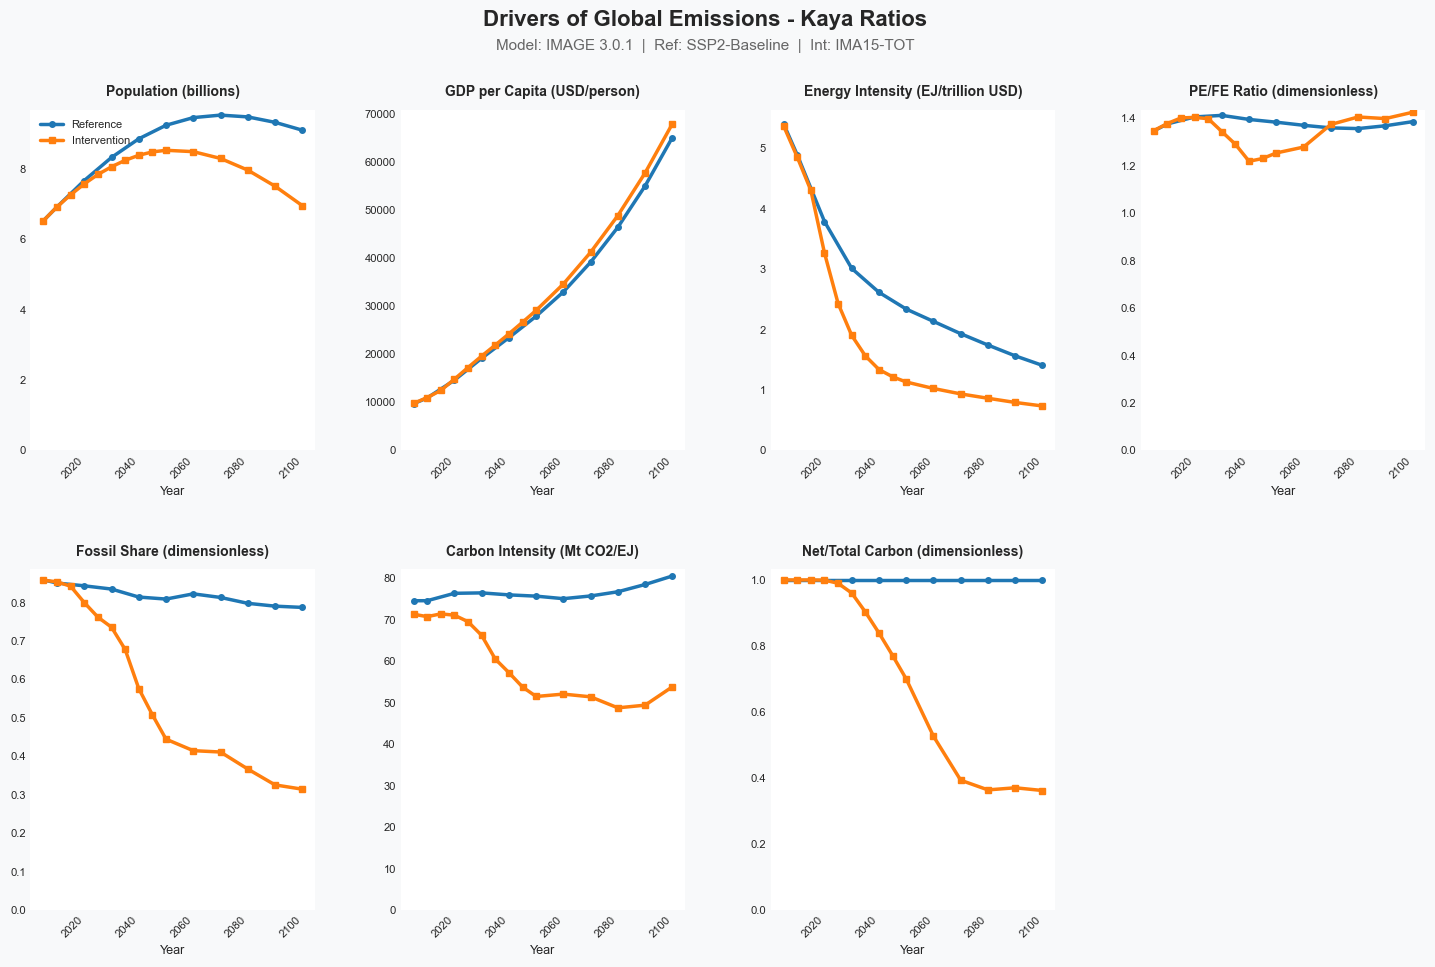

In [19]:
ratio_names = ["P", "GNP/P", "FE/GNP", "PEDEq/FE", "PEFF/PEDEq", "TFC/PEFF", "NFC/TFC"]
ratio_labels = {
    "P": "Population (billions)",
    "GNP/P": "GDP per Capita (USD/person)",
    "FE/GNP": "Energy Intensity (EJ/trillion USD)",
    "PEDEq/FE": "PE/FE Ratio (dimensionless)",
    "PEFF/PEDEq": "Fossil Share (dimensionless)",
    "TFC/PEFF": "Carbon Intensity (Mt CO2/EJ)",
    "NFC/TFC": "Net/Total Carbon (dimensionless)",
}

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')

fig.suptitle('Drivers of Global Emissions - Kaya Ratios', fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.94, f'Model: {MODEL}  |  Ref: {REF_SCENARIO}  |  Int: {INT_SCENARIO}',
         ha='center', fontsize=11, color='#666')

gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3, top=0.88, bottom=0.08)

for i, ratio in enumerate(ratio_names):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.set_facecolor('#ffffff')
    
    if ratio == "P":
        ref_data, int_data = ref_factors["P"], int_factors["P"]
    else:
        ref_data, int_data = ref_ratios[ratio], int_ratios[ratio]
    
    ax.plot(ref_data.index, ref_data, color='#1f77b4', linewidth=2.5, 
            label='Reference', marker='o', markersize=4)
    ax.plot(int_data.index, int_data, color='#ff7f0e', linewidth=2.5, 
            label='Intervention', marker='s', markersize=4)
    
    ax.set_title(ratio_labels[ratio], fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylim(0, None)
    
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax_empty = fig.add_subplot(gs[1, 3])
ax_empty.axis('off')

plt.show()